In [1]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.read_csv('data/data_access_logs.csv', parse_dates=['timestamp'])
users = pd.read_csv('data/user_profiles.csv')
df = logs.merge(users, on='user_id', how='left')
print(f"Total events: {len(logs)}")
print(f"Total users: {len(users)}")
print(f"Date range: {logs['timestamp'].min()} to {logs['timestamp'].max()}")
print(f"\nColumns: {logs.columns.tolist()}")

Matplotlib is building the font cache; this may take a moment.


Total events: 1200
Total users: 100
Date range: 2025-04-21 05:58:00 to 2026-04-20 10:54:06

Columns: ['timestamp', 'user_id', 'username', 'action', 'resource', 'resource_sensitivity', 'status', 'source_ip', 'time_classification']


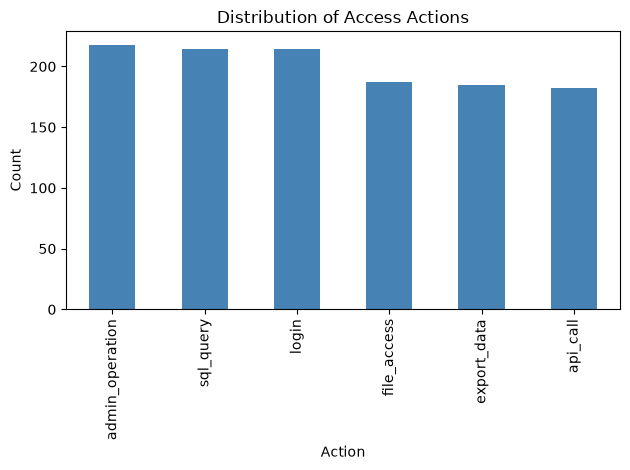

In [2]:
logs['action'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Access Actions')
plt.xlabel('Action')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

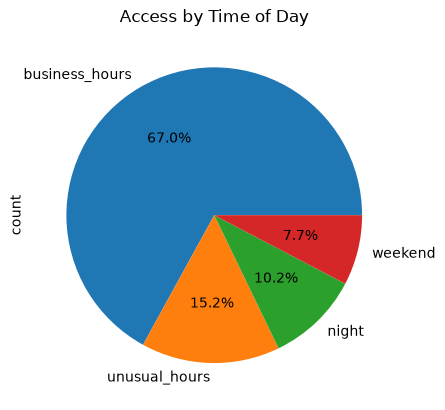

In [3]:
logs['time_classification'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Access by Time of Day')
plt.show()

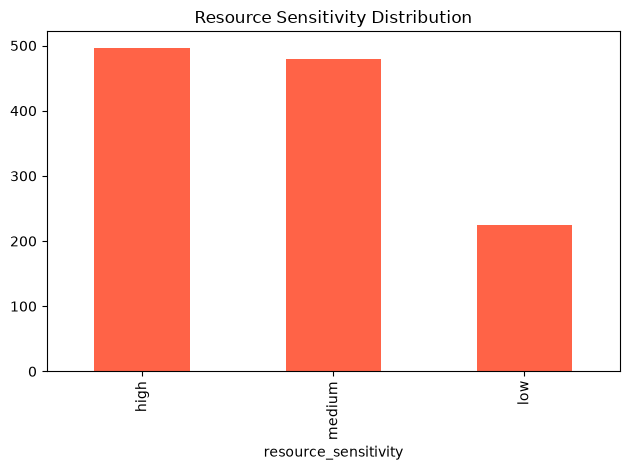

In [4]:
logs['resource_sensitivity'].value_counts().plot(kind='bar', color='tomato')
plt.title('Resource Sensitivity Distribution')
plt.tight_layout()
plt.show()

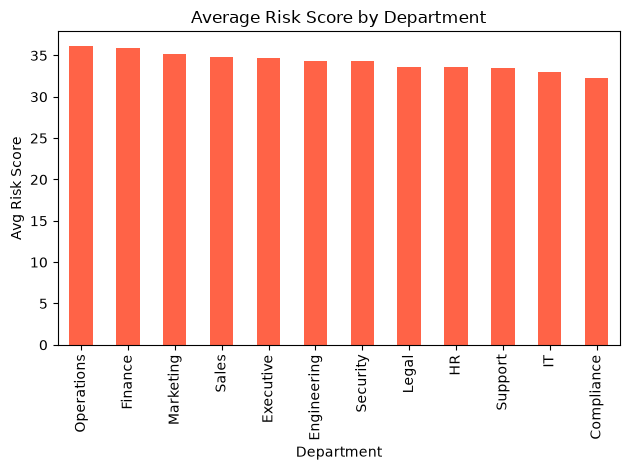

In [5]:
scored = pd.read_csv('outputs/scored_events.csv')
dept_risk = scored.groupby('department')['risk_score'].mean().sort_values(ascending=False)
dept_risk.plot(kind='bar', color='tomato')
plt.title('Average Risk Score by Department')
plt.xlabel('Department')
plt.ylabel('Avg Risk Score')
plt.tight_layout()
plt.show()

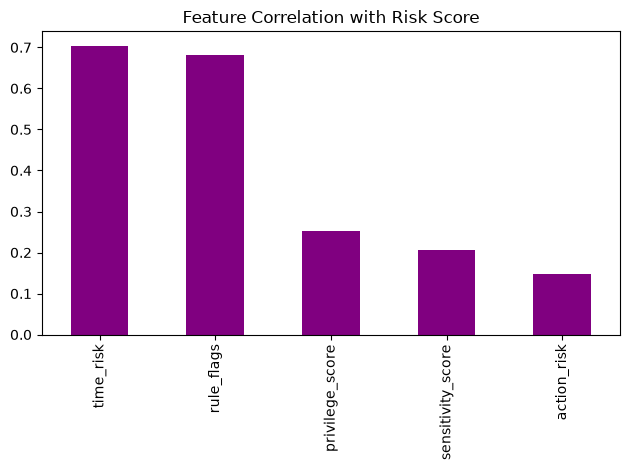

In [6]:
features = ['sensitivity_score','action_risk','time_risk','privilege_score','rule_flags']
features = [f for f in features if f in scored.columns]
corr = scored[features + ['risk_score']].corr()['risk_score'].drop('risk_score').sort_values(ascending=False)
corr.plot(kind='bar', color='purple')
plt.title('Feature Correlation with Risk Score')
plt.tight_layout()
plt.show()

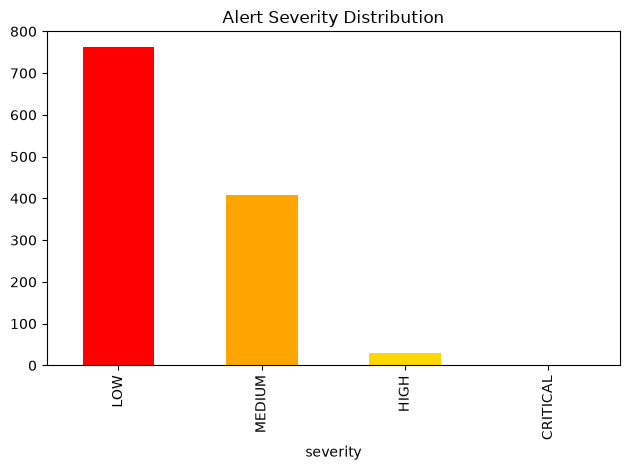

severity
LOW         762
MEDIUM      407
HIGH         30
CRITICAL      1
Name: count, dtype: int64


In [7]:
scored['severity'].value_counts().plot(kind='bar', color=['red','orange','gold','green'])
plt.title('Alert Severity Distribution')
plt.tight_layout()
plt.show()
print(scored['severity'].value_counts())

Total failed events: 62
Failure rate: 5.2%


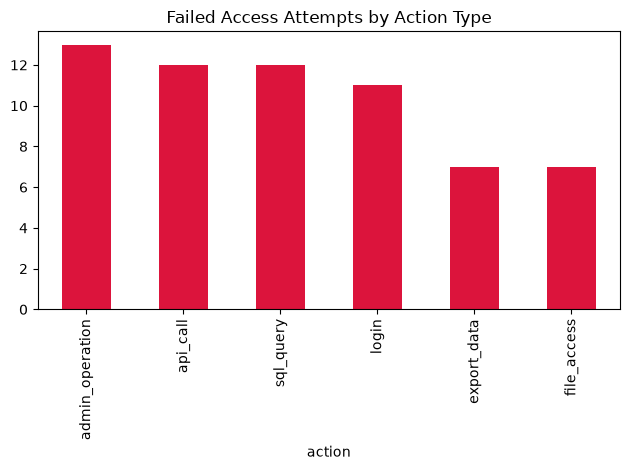

In [8]:
# Failed access events analysis
print(f"Total failed events: {(logs['status'] == 'failure').sum()}")
print(f"Failure rate: {(logs['status'] == 'failure').mean():.1%}")
logs.groupby('action')['status'].apply(lambda x: (x=='failure').sum()).sort_values(ascending=False).plot(kind='bar', color='crimson')
plt.title('Failed Access Attempts by Action Type')
plt.tight_layout()
plt.show()